# Introduction

## Pneumonia Detection Using Deep Learning on Chest X-Ray Images

Pneumonia is a life-threatening respiratory infection and remains one of the leading causes of death worldwide, particularly among children, the elderly, and individuals with weakened immune systems. Early and accurate diagnosis is critical for effective treatment and can significantly reduce mortality rates. Chest X-ray imaging is one of the most commonly used diagnostic tools for detecting pneumonia, but manual interpretation can be time-consuming and subject to human error.

With the rapid advancement of Artificial Intelligence and Deep Learning, Convolutional Neural Networks (CNNs) have shown remarkable performance in medical image classification tasks. Automated pneumonia detection systems can assist healthcare professionals by providing fast, consistent, and reliable diagnostic support, ultimately helping to save lives.

---

## Objectives of This Notebook

In this notebook, multiple deep learning approaches are implemented and evaluated to determine the most effective model for detecting pneumonia from Chest X-ray images.

The main components of this project include:

- Explanatory Data Analysis (EDA)
- Building and training **a Convolutional Neural Network (CNN)**
- Utilizing **EfficientNetB0**, a powerful **pretrained Transfer Learning model**, to leverage knowledge from large-scale datasets
- Utilizing **DenseNet121**, a powerful **pretrained Transfer Learning model**, to leverage knowledge from large-scale datasets
- Applying **Albumentations** for advanced data augmentation to improve model generalization and robustness
- Implementing **Grad-CAM (Gradient-weighted Class Activation Mapping)** to visually interpret model predictions and highlight the regions associated with pneumonia detection
- Class Weighting and threshold optimization for fighting class imbalance
- Performing a **comprehensive evaluation** of model performance using:
  - Confusion Matrix
  - ROC Curve
  - Classification Report
  - Accuracy, Precision, Recall, and F1-score

---

## Goal

The primary goal of this project is to develop and evaluate reliable deep learning models capable of assisting in the early detection of pneumonia from Chest X-ray images. By comparing multiple architectures and leveraging modern deep learning techniques, this work aims to identify the most accurate and interpretable model for real-world medical diagnostic support.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import tensorflow as tf
import os

In [3]:
import cv2
import imghdr

# Data Loading

## 1. Setting Up the Data Directory

In [4]:
data_dir='data'

In [5]:
os.listdir(data_dir)

['NORMAL', 'PNEUMONIA', 'test', 'train', 'val']

## 2. Defining Accepted Image Extensions


In [6]:
image_exts = ['jpeg']

## 3. Loading the Dataset

In [7]:
train_data = tf.keras.utils.image_dataset_from_directory('data/train')
val_data   = tf.keras.utils.image_dataset_from_directory('data/val')
test_data  = tf.keras.utils.image_dataset_from_directory('data/test')


print(train_data.class_names)

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
['NORMAL', 'PNEUMONIA']


## 4. Augmentation and Split

In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE   = 150 
BATCH_SIZE = 32
SEED       = 42

TRAIN_DIR  = 'data/train'
TEST_DIR   = 'data/test'

train_datagen = ImageDataGenerator(
    rescale            = 1./255,
    horizontal_flip    = True,
    rotation_range     = 10,
    zoom_range         = 0.1,
    width_shift_range  = 0.1,
    height_shift_range = 0.1,
    brightness_range   = [0.8, 1.2],
    validation_split   = 0.15  
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size  = (IMG_SIZE, IMG_SIZE),
    batch_size   = BATCH_SIZE,
    class_mode   = 'binary',
    subset       = 'training',
    shuffle      = True,
    seed         = SEED
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size  = (IMG_SIZE, IMG_SIZE),
    batch_size   = BATCH_SIZE,
    class_mode   = 'binary',
    subset       = 'validation',
    shuffle      = False,
    seed         = SEED
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,    
    target_size  = (IMG_SIZE, IMG_SIZE),
    batch_size   = BATCH_SIZE,
    class_mode   = 'binary',
    shuffle      = False
)

print(f"\nClass Indices   : {train_generator.class_indices}")
print(f"Train Samples   : {train_generator.samples}")
print(f"Val Samples     : {val_generator.samples}")
print(f"Test Samples    : {test_generator.samples}")

Found 4434 images belonging to 2 classes.
Found 782 images belonging to 2 classes.
Found 624 images belonging to 2 classes.

Class Indices   : {'NORMAL': 0, 'PNEUMONIA': 1}
Train Samples   : 4434
Val Samples     : 782
Test Samples    : 624


# Data Augmentation & Pipeline Explanation

## Overview

This pipeline prepares image data for a **binary image classification** task using TensorFlow/Keras. It handles three data splits — training, validation, and testing — each with appropriate preprocessing.

---

## Constants

```python
IMG_SIZE   = 150
BATCH_SIZE = 32
SEED       = 42
```

| Constant | Value | Reason |
|---|---|---|
| `IMG_SIZE` | 150 | All images are resized to 150×150 pixels to ensure uniform input shape for the model |
| `BATCH_SIZE` | 32 | A standard mini-batch size that balances memory efficiency and gradient stability |
| `SEED` | 42 | Fixes randomness so the train/validation split and shuffling are reproducible across runs |

---

## Training ImageDataGenerator

```python
train_datagen = ImageDataGenerator(
    rescale            = 1./255,
    horizontal_flip    = True,
    rotation_range     = 10,
    zoom_range         = 0.1,
    width_shift_range  = 0.1,
    height_shift_range = 0.1,
    brightness_range   = [0.8, 1.2],
    validation_split   = 0.15
)
```

### `rescale = 1./255`
Pixel values originally range from 0–255. Dividing by 255 normalizes them to [0, 1]. This is essential because neural networks train more stably with small, consistent input values, and it aligns with what most activation functions expect.

### `horizontal_flip = True`
Randomly mirrors images horizontally during training. This teaches the model that left-right orientation is irrelevant to the classification — effectively doubling the diversity of your dataset for free.

### `rotation_range = 10`
Randomly rotates images up to ±10 degrees. This adds robustness to slight tilts or camera angles in real-world images. The range is kept small (10°) to avoid distorting images beyond recognition.

### `zoom_range = 0.1`
Randomly zooms in or out by up to 10%. This simulates subjects appearing at different distances from the camera, encouraging the model to focus on features rather than scale.

### `width_shift_range = 0.1` / `height_shift_range = 0.1`
Randomly shifts images horizontally and vertically by up to 10% of their dimensions. This helps the model generalize to subjects that aren't perfectly centered in the frame.

### `brightness_range = [0.8, 1.2]`
Randomly adjusts brightness between 80% and 120% of the original. This simulates varying lighting conditions (e.g., shadows, overexposure), making the model more robust to real-world illumination differences.

### `validation_split = 0.15`
Reserves 15% of the training directory as a validation set, handled internally by Keras. This avoids the need to manually separate files and ensures the split is consistent when using the same `seed`.

---

## Test ImageDataGenerator

```python
test_datagen = ImageDataGenerator(rescale=1./255)
```

The test generator applies **only rescaling** — no augmentation. This is intentional: the test set must reflect real-world data as-is. Augmenting it would give an unrealistic picture of model performance.

---

## Data Generators (Flows)

### Training Generator
```python
train_generator = train_datagen.flow_from_directory(..., subset='training', shuffle=True)
```
- Uses the 85% training portion of `TRAIN_DIR`
- `shuffle=True` — randomizes sample order each epoch to prevent the model from learning order-dependent patterns

### Validation Generator
```python
val_generator = train_datagen.flow_from_directory(..., subset='validation', shuffle=False)
```
- Uses the held-out 15% of `TRAIN_DIR`
- `shuffle=False` — keeps order consistent so validation metrics are comparable across epochs
- Uses the same `train_datagen` object (with `validation_split` set), but augmentation transforms are **not applied** to the validation subset by Keras — only `rescale` is

### Test Generator
```python
test_generator = test_datagen.flow_from_directory(TEST_DIR, shuffle=False)
```
- Reads from a completely separate `TEST_DIR`
- `shuffle=False` — preserves order so predictions can be correctly mapped back to filenames/labels

---

## Why Augment Only Training Data?

| Split | Augmentation | Reason |
|---|---|---|
| Train |  Full augmentation | Increases data diversity, reduces overfitting |
| Validation |  None (rescale only) | Must reflect real conditions to monitor true generalization |
| Test |  None (rescale only) | Must reflect real conditions for honest final evaluation |

---

## Summary

This pipeline follows best practices for image classification:

1. **Normalize** all splits consistently with `rescale`
2. **Augment only training data** to artificially expand the dataset and improve generalization
3. **Keep augmentations realistic** (small rotations, modest brightness shifts) to avoid producing unnatural training samples
4. **Fix the seed** to ensure reproducibility of the train/val split
5. **Never shuffle validation or test sets** to maintain consistent evaluation

Image batch shape : (32, 150, 150, 3)
Labels batch shape: (32,)

Raw labels: [1. 0. 1. 0. 0. 1. 1. 1. 0. 1. 0. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 0. 1. 1.
 1. 1. 0. 1. 0. 0. 1. 1.]
Unique values: [0. 1.]
Class mapping : {'NORMAL': 0, 'PNEUMONIA': 1}
NORMAL count  : 10
PNEUMONIA count: 22


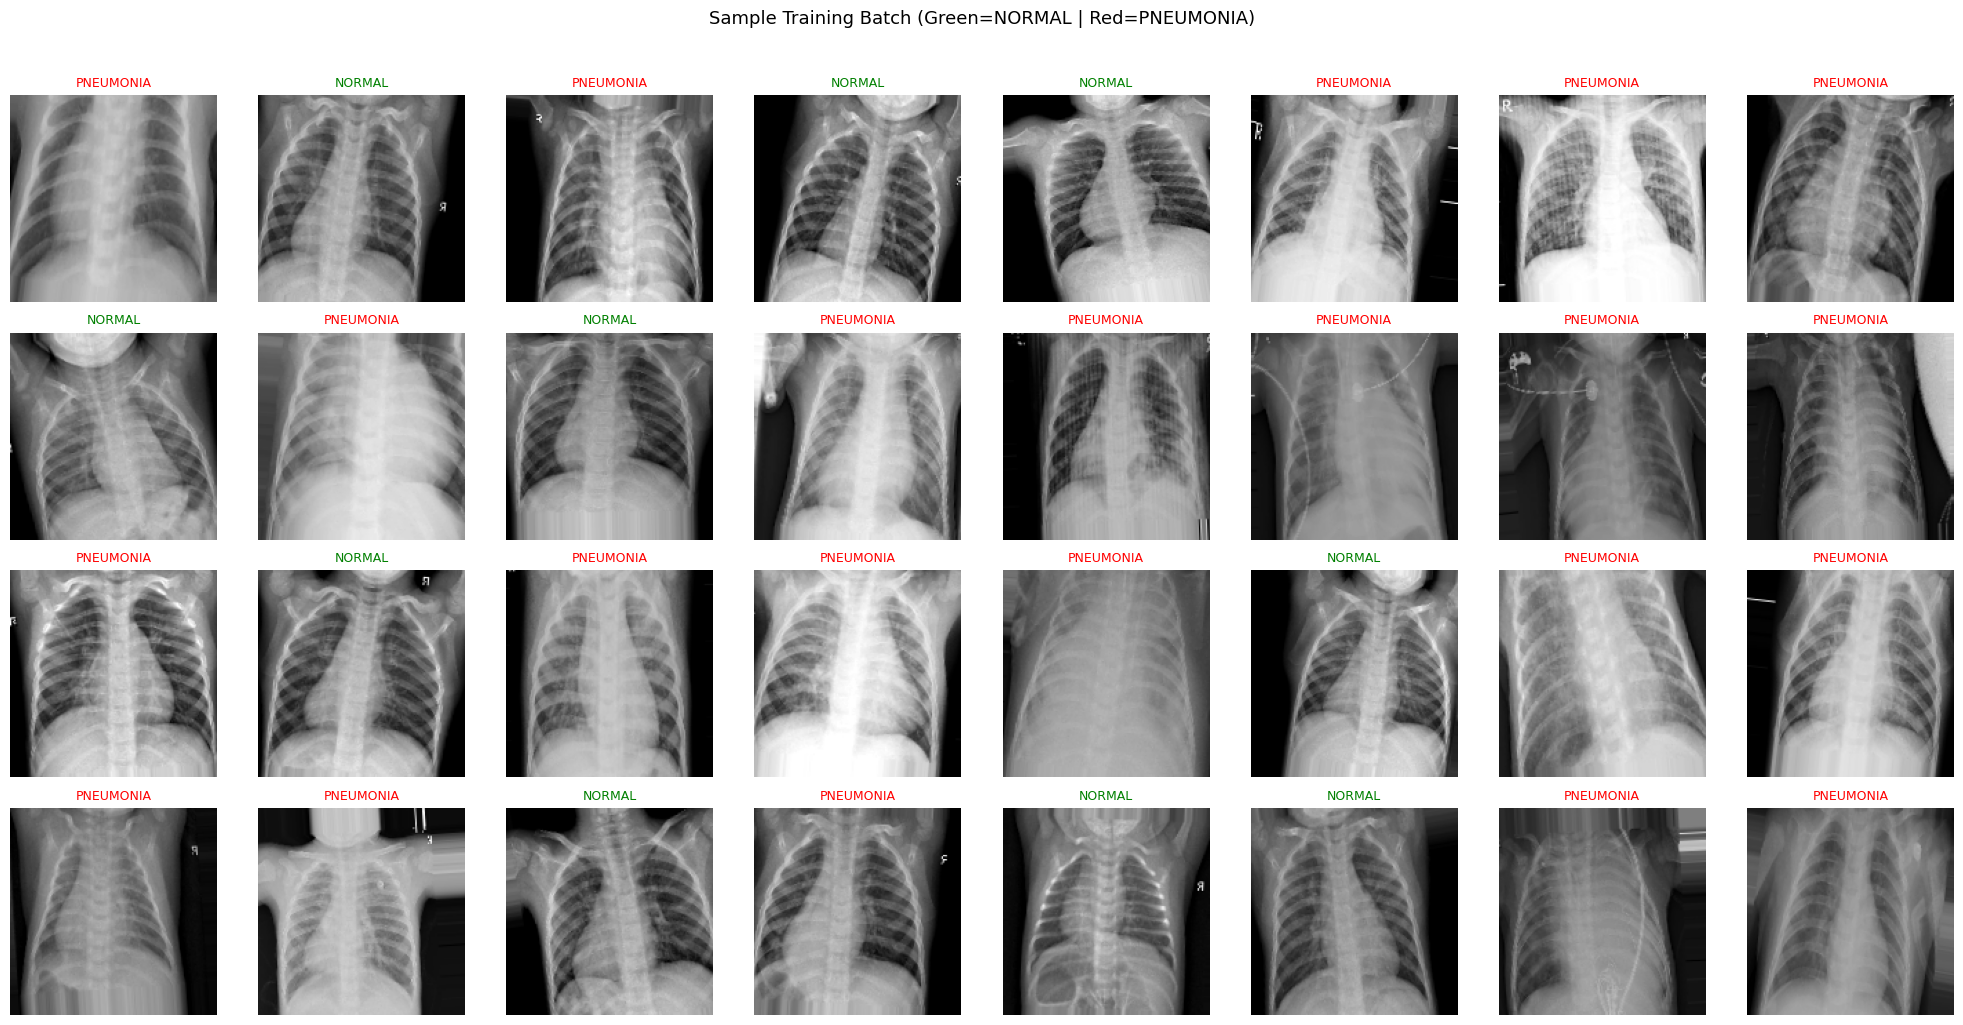

In [9]:
import matplotlib.pyplot as plt
import numpy as np

batch_images, batch_labels = next(train_generator)

print(f"Image batch shape : {batch_images.shape}")
print(f"Labels batch shape: {batch_labels.shape}")

print(f"\nRaw labels: {batch_labels}")
print(f"Unique values: {np.unique(batch_labels)}")
print(f"Class mapping : {train_generator.class_indices}")
print(f"NORMAL count  : {int(np.sum(batch_labels == 0))}")
print(f"PNEUMONIA count: {int(np.sum(batch_labels == 1))}")

class_names = {v: k for k, v in train_generator.class_indices.items()}

fig, axes = plt.subplots(4, 8, figsize=(20, 10))
axes = axes.flatten()

for i, ax in enumerate(axes):
    ax.imshow(batch_images[i])
    label = int(batch_labels[i])
    ax.set_title(class_names[label], 
                 color='red' if label == 1 else 'green',
                 fontsize=9)
    ax.axis('off')

plt.suptitle('Sample Training Batch (Green=NORMAL | Red=PNEUMONIA)', 
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---